In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km';t_res='5min'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'


# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'


In [2]:


times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
job_array=False;index_adjust=0
ocean_fraction=0.25

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [4]:
def check_memory():
    import sys
    ipython_vars = ["In", "Out", "exit", "quit", "get_ipython", "ipython_vars"]
    print("Top 10 objects with highest memory usage")
    # Get a sorted list of the objects and their sizes
    mem = {
        key: round(value/1e6,2)
        for key, value in sorted(
            [
                (x, sys.getsizeof(globals().get(x)))
                for x in globals()
                if not x.startswith("_") and x not in sys.modules and x not in ipython_vars
            ],
            key=lambda x: x[1],
            reverse=True)[:10]
    }
    print({key:f"{value} MB" for key,value in mem.items()})
    print(f"\n{round(sum(mem.values()),2)/1000} GB in use overall")

In [5]:
# Reading Back Data Later
##############
def make_data_dict(var_names,read_type):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            data_dict = {var_name: f[var_name][:] for var_name in var_names}
            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][:].compute().data for k in var_names}
    return data_dict

# read_type='xarray'
read_type='h5py'

In [6]:
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['A_g', 'A_c', 'W', 'QCQI', 'Z', 'Y', 'X', 'z']
data_dict = make_data_dict(var_names,read_type)
A_g, A_c, W, QCQI, Z, Y, X, parcel_z = (data_dict[k] for k in var_names)

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)
check_memory()

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'QCQI': '532.0 MB', 'parcel_z': '532.0 MB', 'NamespaceMagics': '0.0 MB', 'Normalize': '0.0 MB'}

6.916 GB in use overall


In [8]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'VARS_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['QV','TH','TH_E','BUOYANCY','HMC']
data_dict = make_data_dict(var_names,read_type)
QV, TH, TH_E, BUOYANCY, HMC = (data_dict[k] for k in var_names)
check_memory()

Top 10 objects with highest memory usage
{'A_g': '1064.0 MB', 'A_c': '1064.0 MB', 'Z': '1064.0 MB', 'Y': '1064.0 MB', 'X': '1064.0 MB', 'W': '532.0 MB', 'QCQI': '532.0 MB', 'parcel_z': '532.0 MB', 'QV': '532.0 MB', 'TH': '532.0 MB'}

7.98 GB in use overall


In [7]:
################################################################################

In [ ]:
########################
#READING BACK IN
def LoadFinalData(in_file):
    dict = {}
    with h5py.File(in_file, 'r') as f:
        for key in f.keys():
            dict[key] = f[key][:]
    return dict

def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
in_file=dir2+f"parcel_tracking_SUBSET_{res}_{t_res}_{Np_str}"
final_dict=LoadFinalData(in_file)


#DYNAMICALLY CREATING VARIABLES
for key, value in final_dict.items():
    globals()[key] = value

# #DYNAMICALLY PRINTING VARIABLE SIZES
# for key in final_dict:
#     print(f"{key} has {final_dict[key].shape[0]} parcels")

#PRINTING VARIABLE SIZES (ONE BY ONE)
print(f'ALL: {len(ALL_out_arr)} CL parcels and {len(ALL_save_arr)} nonCL parcels')
print(f'SHALLOW: {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')
print(f'DEEP: {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')
print('\n')
print(f'ALL: {len(ALL_SBZ_out_arr)} SBZ parcels and {len(ALL_nonSBZ_out_arr)} nonSBZ parcels')
print(f'SHALLOW: {len(SHALLOW_SBZ_out_arr)} SBZ parcels and {len(SHALLOW_nonSBZ_out_arr)} nonSBZ parcels')
print(f'DEEP: {len(DEEP_SBZ_out_arr)} SBZ parcels and {len(DEEP_nonSBZ_out_arr)} nonSBZ parcels')
print('\n')
print(f'ALL: {len(ALL_ColdPool_out_arr)} ColdPool parcels')
print(f'SHALLOW: {len(SHALLOW_ColdPool_out_arr)} ColdPool parcels')
print(f'DEEP: {len(DEEP_ColdPool_out_arr)} ColdPool parcels')

#APPLYING JOB ARRAY
if "job_array" in globals():
    print('APPLYING JOB ARRAY')
    def job_filter(arr):
        return arr[(arr[:,0]>=start_job)&(arr[:,0]<end_job)]
    for name in [
        'ALL_out_arr', 'ALL_save_arr',
        'SHALLOW_out_arr', 'SHALLOW_save_arr',
        'DEEP_out_arr', 'DEEP_save_arr',
        'ALL_SBZ_out_arr', 'ALL_nonSBZ_out_arr',
        'SHALLOW_SBZ_out_arr', 'SHALLOW_nonSBZ_out_arr',
        'DEEP_SBZ_out_arr', 'DEEP_nonSBZ_out_arr',
        'ALL_ColdPool_out_arr', 'SHALLOW_ColdPool_out_arr', 'DEEP_ColdPool_out_arr'
    ]:
        globals()[name] = job_filter(globals()[name])

In [14]:
#ALL/DEEP/SHALLOW CL vs non-CL Tracked Parcel Plots
################################################################################

In [19]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
def averaged_profile_count(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    counts=out_var[:, 1]
    zlevels=out_var[:, 2]
    return counts,zlevels

In [20]:
def CL_tracked_profile(var_data,type):
    if type=='all':
        out_arr=ALL_out_arr.copy()
        after_array=ALL_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_out_arr.copy()
        after_array=SHALLOW_out_after_array
    elif type=='deep':
        out_arr=DEEP_out_arr.copy()
        after_array=DEEP_out_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

print('ALL')
ALL_profile_array_w=CL_tracked_profile(W,type='all')
ALL_profile_array_qv=CL_tracked_profile(QV,type='all')
ALL_profile_array_qcqi=CL_tracked_profile(QCQI,type='all')
ALL_profile_array_th=CL_tracked_profile(TH,type='all')
ALL_profile_array_th_e=CL_tracked_profile(TH_E,type='all')
ALL_profile_array_buoyancy=CL_tracked_profile(BUOYANCY,type='all')
ALL_profile_array_HMC=CL_tracked_profile(HMC,type='all')
print('SHALLOW')
SHALLOW_profile_array_w=CL_tracked_profile(W,type='shallow')
SHALLOW_profile_array_qv=CL_tracked_profile(QV,type='shallow')
SHALLOW_profile_array_qcqi=CL_tracked_profile(QCQI,type='shallow')
SHALLOW_profile_array_th=CL_tracked_profile(TH,type='shallow')
SHALLOW_profile_array_th_e=CL_tracked_profile(TH_E,type='shallow')
SHALLOW_profile_array_buoyancy=CL_tracked_profile(BUOYANCY,type='shallow')
SHALLOW_profile_array_HMC=CL_tracked_profile(HMC,type='shallow')
print('DEEP')
DEEP_profile_array_w=CL_tracked_profile(W,type='deep')
DEEP_profile_array_qv=CL_tracked_profile(QV,type='deep')
DEEP_profile_array_qcqi=CL_tracked_profile(QCQI,type='deep')
DEEP_profile_array_th=CL_tracked_profile(TH,type='deep')
DEEP_profile_array_th_e=CL_tracked_profile(TH_E,type='deep')
DEEP_profile_array_buoyancy=CL_tracked_profile(BUOYANCY,type='deep')
DEEP_profile_array_HMC=CL_tracked_profile(HMC,type='deep')

ALL
SHALLOW
DEEP


In [21]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels
    
def CL_tracked_profile_SE(profile_data,var_data,type):  
    global test
    if type=='all':
        out_arr=ALL_out_arr.copy()
        after_array=ALL_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_out_arr.copy()
        after_array=SHALLOW_out_after_array
    elif type=='deep':
        out_arr=DEEP_out_arr.copy()
        after_array=DEEP_out_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;

    # test=[] #TESTING
    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        mean_mu=profile_data[zs,0]/profile_data[zs,1]

        # for count,z in enumerate(zs): #TESTING
        #     if z==28:
        #         test.append(np.array(vars)[count])
        np.add.at(profile_array[:, 0], zs,  (vars-mean_mu)**2) #SUMMING UP THE SQUARES
        np.add.at(profile_array[:, 1], zs,  1) #SUMMING UP THE SQUARES
    return profile_array


ALL_SE_w=CL_tracked_profile_SE(ALL_profile_array_w,W,type='all')
SHALLOW_SE_w=CL_tracked_profile_SE(SHALLOW_profile_array_w,W,type='shallow')
DEEP_SE_w=CL_tracked_profile_SE(DEEP_profile_array_w,W,type='deep')

ALL_SE_qv=CL_tracked_profile_SE(ALL_profile_array_qv,QV,type='all')
SHALLOW_SE_qv=CL_tracked_profile_SE(SHALLOW_profile_array_qv,QV,type='shallow')
DEEP_SE_qv=CL_tracked_profile_SE(DEEP_profile_array_qv,QV,type='deep')

ALL_SE_qcqi=CL_tracked_profile_SE(ALL_profile_array_qcqi,QCQI,type='all')
SHALLOW_SE_qcqi=CL_tracked_profile_SE(SHALLOW_profile_array_qcqi,QCQI,type='shallow')
DEEP_SE_qcqi=CL_tracked_profile_SE(DEEP_profile_array_qcqi,QCQI,type='deep')

ALL_SE_th=CL_tracked_profile_SE(ALL_profile_array_th,TH,type='all')
SHALLOW_SE_th=CL_tracked_profile_SE(SHALLOW_profile_array_th,TH,type='shallow')
DEEP_SE_th=CL_tracked_profile_SE(DEEP_profile_array_th,TH,type='deep')

ALL_SE_th_e=CL_tracked_profile_SE(ALL_profile_array_th_e,TH_E,type='all')
SHALLOW_SE_th_e=CL_tracked_profile_SE(SHALLOW_profile_array_th_e,TH_E,type='shallow')
DEEP_SE_th_e=CL_tracked_profile_SE(DEEP_profile_array_th_e,TH_E,type='deep')

ALL_SE_buoyancy=CL_tracked_profile_SE(ALL_profile_array_buoyancy,BUOYANCY,type='all')
SHALLOW_SE_buoyancy=CL_tracked_profile_SE(SHALLOW_profile_array_buoyancy,BUOYANCY,type='shallow')
DEEP_SE_buoyancy=CL_tracked_profile_SE(DEEP_profile_array_buoyancy,BUOYANCY,type='deep')

ALL_SE_HMC=CL_tracked_profile_SE(ALL_profile_array_HMC,HMC,type='all')
SHALLOW_SE_HMC=CL_tracked_profile_SE(SHALLOW_profile_array_HMC,HMC,type='shallow')
DEEP_SE_HMC=CL_tracked_profile_SE(DEEP_profile_array_HMC,HMC,type='deep')

In [22]:
#MAKING PROFILE ARRAY

def nonCL_tracked_profile(var_data,type):
    if type=='all':
        out_arr=ALL_save_arr.copy()
        after_array=ALL_save_after_array
    elif type=='shallow':
        out_arr=SHALLOW_save_arr.copy()
        after_array=SHALLOW_save_after_array
    elif type=='deep':
        out_arr=DEEP_save_arr.copy()
        after_array=DEEP_save_after_array
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        after=out_arr[row,3]
        p=out_arr[row,0]

        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

print('ALL')
nonCL_ALL_profile_array_w=nonCL_tracked_profile(W,type='all')
nonCL_ALL_profile_array_qv=nonCL_tracked_profile(QV,type='all')
nonCL_ALL_profile_array_qcqi=nonCL_tracked_profile(QCQI,type='all')
nonCL_ALL_profile_array_th=nonCL_tracked_profile(TH,type='all')
nonCL_ALL_profile_array_th_e=nonCL_tracked_profile(TH_E,type='all')
nonCL_ALL_profile_array_buoyancy=nonCL_tracked_profile(BUOYANCY,type='all')
nonCL_ALL_profile_array_HMC=nonCL_tracked_profile(HMC,type='all')
print('SHALLOW')
nonCL_SHALLOW_profile_array_w=nonCL_tracked_profile(W,type='shallow')
nonCL_SHALLOW_profile_array_qv=nonCL_tracked_profile(QV,type='shallow')
nonCL_SHALLOW_profile_array_qcqi=nonCL_tracked_profile(QCQI,type='shallow')
nonCL_SHALLOW_profile_array_th=nonCL_tracked_profile(TH,type='shallow')
nonCL_SHALLOW_profile_array_th_e=nonCL_tracked_profile(TH_E,type='shallow')
nonCL_SHALLOW_profile_array_buoyancy=nonCL_tracked_profile(BUOYANCY,type='shallow')
nonCL_SHALLOW_profile_array_HMC=nonCL_tracked_profile(HMC,type='shallow')
print('DEEP')
nonCL_DEEP_profile_array_w=nonCL_tracked_profile(W,type='deep')
nonCL_DEEP_profile_array_qv=nonCL_tracked_profile(QV,type='deep')
nonCL_DEEP_profile_array_qcqi=nonCL_tracked_profile(QCQI,type='deep')
nonCL_DEEP_profile_array_th=nonCL_tracked_profile(TH,type='deep')
nonCL_DEEP_profile_array_th_e=nonCL_tracked_profile(TH_E,type='deep')
nonCL_DEEP_profile_array_buoyancy=nonCL_tracked_profile(BUOYANCY,type='deep')
nonCL_DEEP_profile_array_HMC=nonCL_tracked_profile(HMC,type='deep')

ALL
SHALLOW
DEEP


In [23]:
#TESTING    
def nonCL_tracked_profile_SE(profile_data,var_data,type):    
    if type=='all':
        out_arr=ALL_save_arr.copy()
        after_array=ALL_save_after_array
    elif type=='shallow':
        out_arr=SHALLOW_save_arr.copy()
        after_array=SHALLOW_save_after_array
    elif type=='deep':
        out_arr=DEEP_save_arr.copy()
        after_array=DEEP_save_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;

    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        mean_mu=profile_data[zs,0]/profile_data[zs,1]
        np.add.at(profile_array[:, 0], zs,  (vars-mean_mu)**2) #SUMMING UP THE SQUARES
        np.add.at(profile_array[:, 1], zs,  1) #SUMMING UP THE SQUARES
    return profile_array


nonCL_ALL_SE_w=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_w,W,type='all')
nonCL_SHALLOW_SE_w=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_w,W,type='shallow')
nonCL_DEEP_SE_w=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_w,W,type='deep')

nonCL_ALL_SE_qv=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_qv,QV,type='all')
nonCL_SHALLOW_SE_qv=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_qv,QV,type='shallow')
nonCL_DEEP_SE_qv=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_qv,QV,type='deep')

nonCL_ALL_SE_qcqi=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_qcqi,QCQI,type='all')
nonCL_SHALLOW_SE_qcqi=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_qcqi,QCQI,type='shallow')
nonCL_DEEP_SE_qcqi=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_qcqi,QCQI,type='deep')

nonCL_ALL_SE_th=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_th,TH,type='all')
nonCL_SHALLOW_SE_th=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_th,TH,type='shallow')
nonCL_DEEP_SE_th=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_th,TH,type='deep')

nonCL_ALL_SE_th_e=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_th_e,TH_E,type='all')
nonCL_SHALLOW_SE_th_e=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_th_e,TH_E,type='shallow')
nonCL_DEEP_SE_th_e=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_th_e,TH_E,type='deep')

nonCL_ALL_SE_buoyancy=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_buoyancy,BUOYANCY,type='all')
nonCL_SHALLOW_SE_buoyancy=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_buoyancy,BUOYANCY,type='shallow')
nonCL_DEEP_SE_buoyancy=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_buoyancy,BUOYANCY,type='deep')

nonCL_ALL_SE_HMC=nonCL_tracked_profile_SE(nonCL_ALL_profile_array_HMC,HMC,type='all')
nonCL_SHALLOW_SE_HMC=nonCL_tracked_profile_SE(nonCL_SHALLOW_profile_array_HMC,HMC,type='shallow')
nonCL_DEEP_SE_HMC=nonCL_tracked_profile_SE(nonCL_DEEP_profile_array_HMC,HMC,type='deep')

In [24]:
#SAVING

# Define categories and variables
types = ["ALL", "SHALLOW", "DEEP"]
variables = ["w", "qv", "qcqi", "th", "th_e", "buoyancy", "HMC"]

# Dictionary to store all variables
tracked_profiles = {}

# Populate all profiles in one loop
for type in types:
    for var in variables:
        tracked_profiles[f"{type}_profile_array_{var}"] = eval(f"{type}_profile_array_{var}")
        tracked_profiles[f"{type}_SE_{var}"] = eval(f"{type}_SE_{var}")
        tracked_profiles[f"nonCL_{type}_profile_array_{var}"] = eval(f"nonCL_{type}_profile_array_{var}")
        tracked_profiles[f"nonCL_{type}_SE_{var}"] = eval(f"nonCL_{type}_SE_{var}")

# Save all variables in an HDF5 file
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
output_file=dir2+f"CL_nonCL_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(output_file, "w") as h5f:
    for name, profile_data in tracked_profiles.items():
        h5f.create_dataset(name, data=profile_data)
print('done')


done


In [ ]:
##################################
#PLOTTING

In [24]:
types = ["ALL", "SHALLOW", "DEEP"]
variables = ["w", "qv", "qcqi", "th", "th_e", "buoyancy", "HMC"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"{t}_profile_array_{var}")
        vars_list.append(f"nonCL_{t}_profile_array_{var}")
for t in types:
    for var in variables:
        SE_list.append(f"{t}_SE_{var}")
        SE_list.append(f"nonCL_{t}_SE_{var}")

# Define directory and output file path
dir2 = dir + 'Project_Algorithms/Tracked_Profiles/job_out2/'
output_file = dir2 + f"CL_nonCL_tracked_profiles_{res}_{Np_str}_.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list + SE_list:
        globals()[var] = f[f'{var}'][:]


In [25]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels

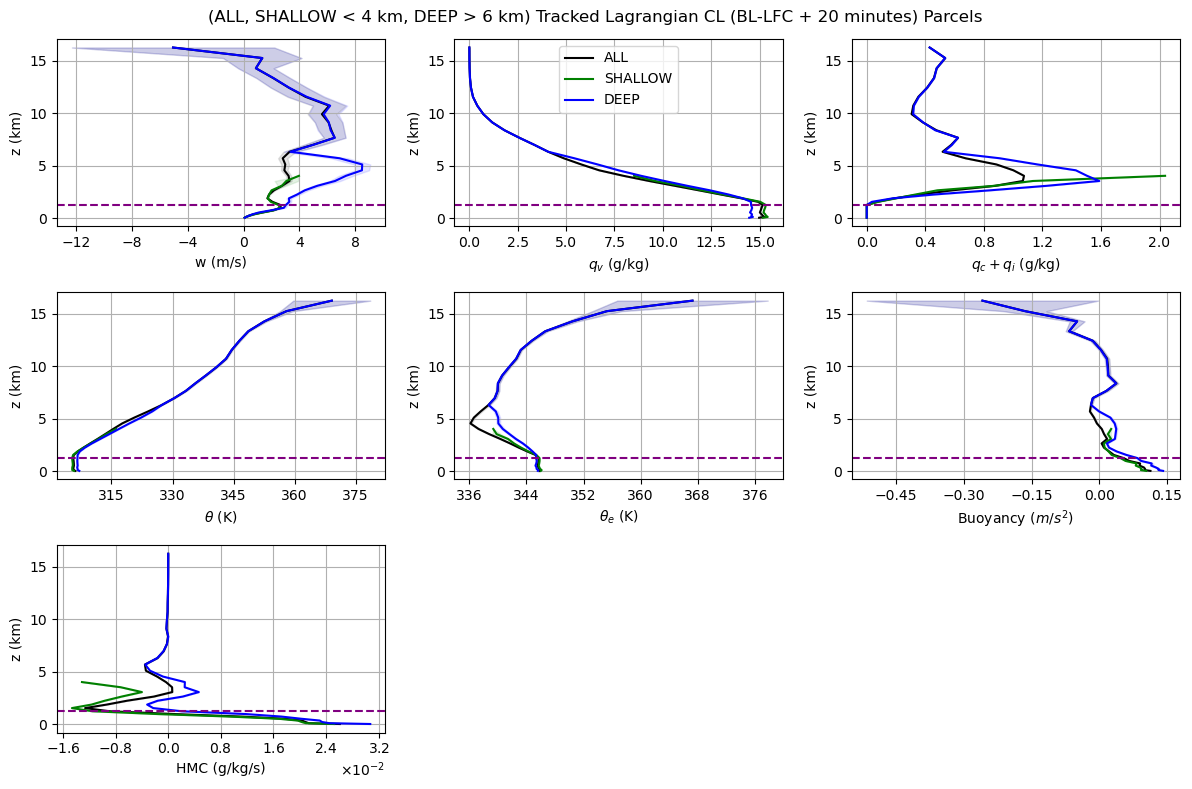

In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_profile_array_w.copy(), SHALLOW_profile_array_w.copy(), DEEP_profile_array_w.copy(), 'w (m/s)'),
    (ALL_profile_array_qv.copy(), SHALLOW_profile_array_qv.copy(), DEEP_profile_array_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_profile_array_qcqi.copy(), SHALLOW_profile_array_qcqi.copy(), DEEP_profile_array_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_profile_array_th.copy(), SHALLOW_profile_array_th.copy(), DEEP_profile_array_th.copy(), r'$\theta$ (K)'),
    (ALL_profile_array_th_e.copy(), SHALLOW_profile_array_th_e.copy(), DEEP_profile_array_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_profile_array_buoyancy.copy(), SHALLOW_profile_array_buoyancy.copy(), DEEP_profile_array_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_profile_array_HMC.copy(), SHALLOW_profile_array_HMC.copy(), DEEP_profile_array_HMC.copy(), 'HMC (g/kg/s)'),
]

############################################################
SE_profiles = [
    (ALL_SE_w.copy(), SHALLOW_SE_w.copy(), DEEP_SE_w.copy(), None),  # Add None for xlabel placeholder
    (ALL_SE_qv.copy(), SHALLOW_SE_qv.copy(), DEEP_SE_qv.copy(), None),
    (ALL_SE_qcqi.copy(), SHALLOW_SE_qcqi.copy(), DEEP_SE_qcqi.copy(), None),
    (ALL_SE_th.copy(), SHALLOW_SE_th.copy(), DEEP_SE_th.copy(), None),
    (ALL_SE_th_e.copy(), SHALLOW_SE_th_e.copy(), DEEP_SE_th_e.copy(), None),
    (ALL_SE_buoyancy.copy(), SHALLOW_SE_buoyancy.copy(), DEEP_SE_buoyancy.copy(), None),
    (ALL_SE_HMC.copy(), SHALLOW_SE_HMC.copy(), DEEP_SE_HMC.copy(), None),
]
############################################################


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

#MATCHING X AXISES WITH NEXT PLOT
#(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
for axis in axs:
    nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
if 'ax8' in globals():
    fix_x_limits([ax1,ax8])
    fix_x_limits([ax2,ax9])
    fix_x_limits([ax3,ax10])
    fix_x_limits([ax4,ax11])
    fix_x_limits([ax5,ax12])
    fix_x_limits([ax6,ax13])
    fix_x_limits([ax7,ax14])
    del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


(-13.379295321764559, 11.155642729066823)
(-0.8055920207011387, 16.942239713529293)
(-0.18384546749248534, 3.8607556935044767)
(300.566970057218, 382.486723046615)
(330.4207111122001, 380.3394001398928)
(-0.8346858421889063, 0.20397126659447415)
(-0.0390030328107855, 0.03300076627298889)


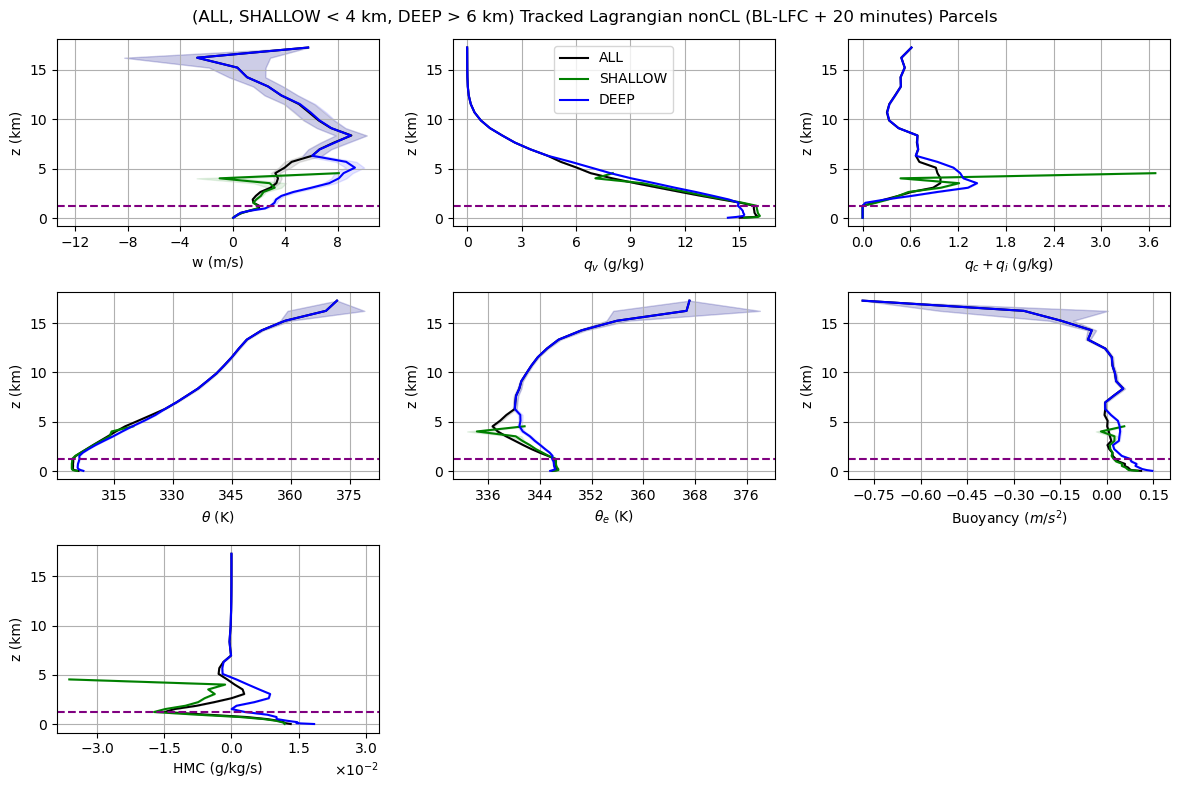

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (nonCL_ALL_profile_array_w.copy(), nonCL_SHALLOW_profile_array_w.copy(), nonCL_DEEP_profile_array_w.copy(), 'w (m/s)'),
    (nonCL_ALL_profile_array_qv.copy(), nonCL_SHALLOW_profile_array_qv.copy(), nonCL_DEEP_profile_array_qv.copy(), r'$q_v$ (g/kg)'),
    (nonCL_ALL_profile_array_qcqi.copy(), nonCL_SHALLOW_profile_array_qcqi.copy(), nonCL_DEEP_profile_array_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (nonCL_ALL_profile_array_th.copy(), nonCL_SHALLOW_profile_array_th.copy(), nonCL_DEEP_profile_array_th.copy(), r'$\theta$ (K)'),
    (nonCL_ALL_profile_array_th_e.copy(), nonCL_SHALLOW_profile_array_th_e.copy(), nonCL_DEEP_profile_array_th_e.copy(), r'$\theta_e$ (K)'),
    (nonCL_ALL_profile_array_buoyancy.copy(), nonCL_SHALLOW_profile_array_buoyancy.copy(), nonCL_DEEP_profile_array_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (nonCL_ALL_profile_array_HMC.copy(), nonCL_SHALLOW_profile_array_HMC.copy(), nonCL_DEEP_profile_array_HMC.copy(), 'HMC (g/kg/s)'),
]

############################################################
SE_profiles = [
    (nonCL_ALL_SE_w.copy(), nonCL_SHALLOW_SE_w.copy(), nonCL_DEEP_SE_w.copy(), None),  # Add None for xlabel placeholder
    (nonCL_ALL_SE_qv.copy(), nonCL_SHALLOW_SE_qv.copy(), nonCL_DEEP_SE_qv.copy(), None),
    (nonCL_ALL_SE_qcqi.copy(), nonCL_SHALLOW_SE_qcqi.copy(), nonCL_DEEP_SE_qcqi.copy(), None),
    (nonCL_ALL_SE_th.copy(), nonCL_SHALLOW_SE_th.copy(), nonCL_DEEP_SE_th.copy(), None),
    (nonCL_ALL_SE_th_e.copy(), nonCL_SHALLOW_SE_th_e.copy(), nonCL_DEEP_SE_th_e.copy(), None),
    (nonCL_ALL_SE_buoyancy.copy(), nonCL_SHALLOW_SE_buoyancy.copy(), nonCL_DEEP_SE_buoyancy.copy(), None),
    (nonCL_ALL_SE_HMC.copy(), nonCL_SHALLOW_SE_HMC.copy(), nonCL_DEEP_SE_HMC.copy(), None),
]
############################################################

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax8, ax9, ax10, ax11, ax12, ax13, ax14 = axs
for axis in [ax8, ax9, ax10, ax11, ax12, ax13, ax14]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# #FIXING X AXISES TO MATCH PREVIOUS PLOTS
for axis in axs:
    nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
fix_x_limits([ax1,ax8])
fix_x_limits([ax2,ax9])
fix_x_limits([ax3,ax10])
fix_x_limits([ax4,ax11])
fix_x_limits([ax5,ax12])
fix_x_limits([ax6,ax13])
fix_x_limits([ax7,ax14])

In [28]:
#DIFFERENCES

def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

# Calculate average differences for each variable (w, qv, qc, th, buoyancy)
ALL_diff_w = average_difference(ALL_profile_array_w, nonCL_ALL_profile_array_w)
SHALLOW_diff_w = average_difference(SHALLOW_profile_array_w, nonCL_SHALLOW_profile_array_w)
DEEP_diff_w= average_difference(DEEP_profile_array_w, nonCL_DEEP_profile_array_w)

ALL_diff_qv = average_difference(ALL_profile_array_qv, nonCL_ALL_profile_array_qv)
SHALLOW_diff_qv = average_difference(SHALLOW_profile_array_qv, nonCL_SHALLOW_profile_array_qv)
DEEP_diff_qv = average_difference(DEEP_profile_array_qv, nonCL_DEEP_profile_array_qv)

ALL_diff_qcqi = average_difference(ALL_profile_array_qcqi, nonCL_ALL_profile_array_qcqi)
SHALLOW_diff_qcqi = average_difference(SHALLOW_profile_array_qcqi, nonCL_SHALLOW_profile_array_qcqi)
DEEP_diff_qcqi = average_difference(DEEP_profile_array_qcqi, nonCL_DEEP_profile_array_qcqi)

ALL_diff_th = average_difference(ALL_profile_array_th, nonCL_ALL_profile_array_th)
SHALLOW_diff_th = average_difference(SHALLOW_profile_array_th, nonCL_SHALLOW_profile_array_th)
DEEP_diff_th = average_difference(DEEP_profile_array_th, nonCL_DEEP_profile_array_th)

ALL_diff_th_e = average_difference(ALL_profile_array_th_e, nonCL_ALL_profile_array_th_e)
SHALLOW_diff_th_e = average_difference(SHALLOW_profile_array_th_e, nonCL_SHALLOW_profile_array_th_e)
DEEP_diff_th_e = average_difference(DEEP_profile_array_th_e, nonCL_DEEP_profile_array_th_e)

ALL_diff_buoyancy = average_difference(ALL_profile_array_buoyancy, nonCL_ALL_profile_array_buoyancy)
SHALLOW_diff_buoyancy = average_difference(SHALLOW_profile_array_buoyancy, nonCL_SHALLOW_profile_array_buoyancy)
DEEP_diff_buoyancy = average_difference(DEEP_profile_array_buoyancy, nonCL_DEEP_profile_array_buoyancy)

ALL_diff_HMC = average_difference(ALL_profile_array_HMC, nonCL_ALL_profile_array_HMC)
SHALLOW_diff_HMC = average_difference(SHALLOW_profile_array_HMC, nonCL_SHALLOW_profile_array_HMC)
DEEP_diff_HMC = average_difference(DEEP_profile_array_HMC, nonCL_DEEP_profile_array_HMC)

print('done')

done


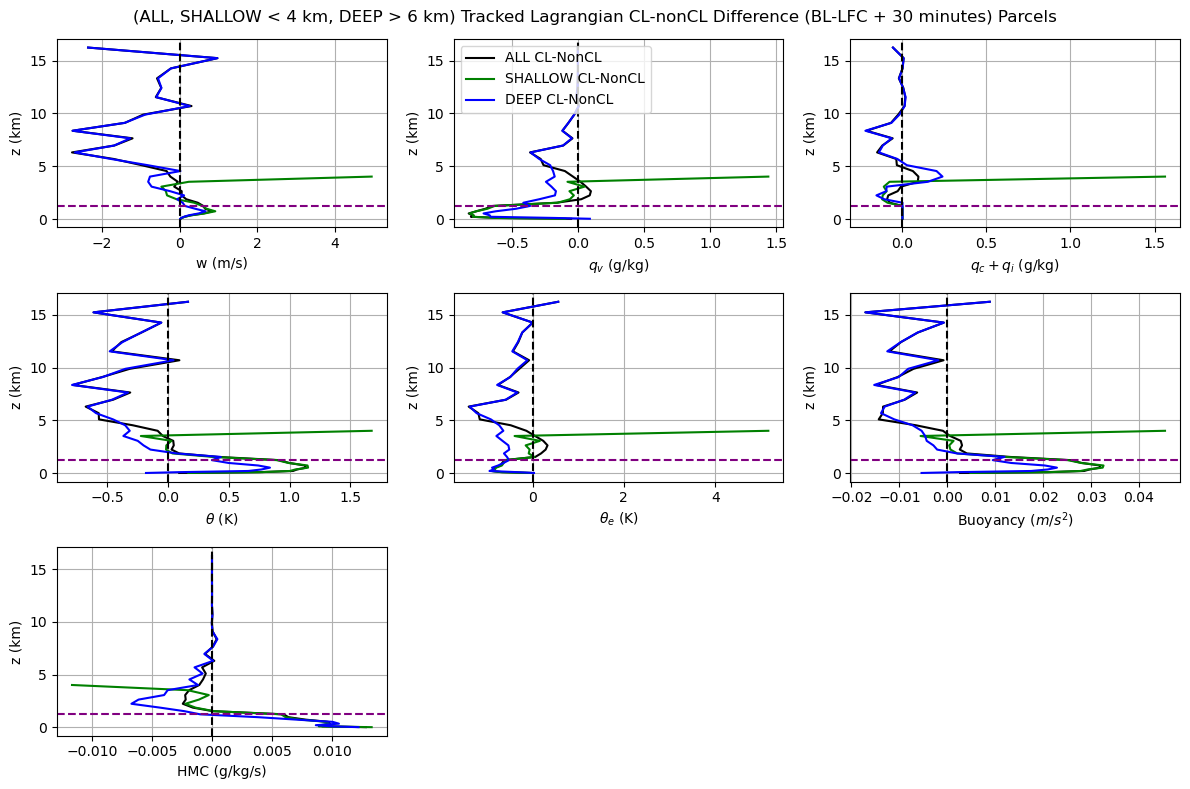

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_diff_w.copy(), SHALLOW_diff_w.copy(), DEEP_diff_w.copy(), 'w (m/s)'),
    (ALL_diff_qv.copy(), SHALLOW_diff_qv.copy(), DEEP_diff_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_diff_qcqi.copy(), SHALLOW_diff_qcqi.copy(), DEEP_diff_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_diff_th.copy(), SHALLOW_diff_th.copy(), DEEP_diff_th.copy(), r'$\theta$ (K)'),
    (ALL_diff_th_e.copy(), SHALLOW_diff_th_e.copy(), DEEP_diff_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_diff_buoyancy.copy(), SHALLOW_diff_buoyancy.copy(), DEEP_diff_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_diff_HMC.copy(), SHALLOW_diff_HMC.copy(), DEEP_diff_HMC.copy(), 'HMC (g/kg/s)'),
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL-nonCL Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [29]:
# #TESTING COMPARING ONE PROPERTY ONLY
# CL_vars=(ALL_profile_array_w, SHALLOW_profile_array_w, DEEP_profile_array_w, r'$w$ (m/s)')
# nonCL_vars=(nonCL_ALL_profile_array_w, nonCL_SHALLOW_profile_array_w, nonCL_DEEP_profile_array_w, r'$w$ (m/s)')
# diffs=(ALL_diff_w, SHALLOW_diff_w, DEEP_diff_w, r'$w$ (m/s)')

# # CL_vars=(ALL_profile_array_qv, SHALLOW_profile_array_qv, DEEP_profile_array_qv, r'$q_v$ (g/kg)')
# # nonCL_vars=(nonCL_ALL_profile_array_qv, nonCL_SHALLOW_profile_array_qv, nonCL_DEEP_profile_array_qv, r'$q_v$ (g/kg)')
# # diffs=(ALL_diff_qv, SHALLOW_diff_qv, DEEP_diff_qv, r'$q_v$ (g/kg)')
# colors=['black','green','blue']
# types=['ALL','SHALLOW','DEEP']


# plt.figure(figsize=(10, 6))  # Make the figure wider to fit two subplots

# # First subplot: Original plot
# plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
# for i in np.arange(len(CL_vars) - 1):
#     variable = averaged_profiles(CL_vars[i]).copy()
#     # variable[:, 0] *= 1000
#     plt.plot(variable[:, 0], variable[:, 1], color=colors[i], label=f'{types[i]} CL')

#     variable = averaged_profiles(nonCL_vars[i]).copy()
#     # variable[:, 0] *= 1000
#     plt.plot(variable[:, 0], variable[:, 1], linestyle='dashed', color=colors[i], label=f'{types[i]} nonCL')

# plt.legend()
# plt.ylabel('z (km)')
# plt.xlabel(CL_vars[-1])

# # Second subplot: Temporary plot
# plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
# for i in np.arange(len(CL_vars) - 1):
#     variable = diffs[i].copy()
#     # variable[:, 0] *= 1000
#     plt.plot(variable[:, 0], variable[:, 1], color=colors[i], label=f'{types[i]} CL - nonCL')

# plt.axvline(0,color='grey',zorder=0)
# plt.legend()
# plt.ylabel('z (km)')
# plt.xlabel(CL_vars[-1])


# plt.suptitle(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for {diffs[-1]} from Tracked Lagrangian Parcels')# \n (Parcels are Tracked Through Updrafts Originating in the Boundary Layer)')
# plt.tight_layout()

In [ ]:
#SBZ vs nonSBZ
################################################################################

In [32]:
#FINDING MEAN CLOUD BASE #*****************************
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'

if type=='all':
    out_arr=ALL_out_arr.copy()
elif type=='deep':
    out_arr=DEEP_out_arr.copy()
elif type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=20*int(minutes) #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14894
3000/14894
6000/14894
9000/14894
12000/14894
1.2463868


In [33]:
#PLOTTING SBZ vs non-SBZ Vertical Profiles
##########################################

#SBZ
def SBZ_tracked_profile(var_data,type):

    if type=='all':
        out_arr=ALL_SBZ_out_arr.copy()
        after_array=ALL_SBZ_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_SBZ_out_arr.copy()
        after_array=SHALLOW_SBZ_out_after_array
    elif type=='deep':
        out_arr=DEEP_SBZ_out_arr.copy()
        after_array=DEEP_SBZ_out_after_array
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array


print('ALL')
ALL_profile_array_w=SBZ_tracked_profile(W,type='all')
ALL_profile_array_qv=SBZ_tracked_profile(QV,type='all')
ALL_profile_array_qcqi=SBZ_tracked_profile(QCQI,type='all')
ALL_profile_array_th=SBZ_tracked_profile(TH,type='all')
ALL_profile_array_th_e=SBZ_tracked_profile(TH_E,type='all')
ALL_profile_array_buoyancy=SBZ_tracked_profile(BUOYANCY,type='all')
ALL_profile_array_HMC=SBZ_tracked_profile(HMC,type='all')

print('SHALLOW')
SHALLOW_profile_array_w=SBZ_tracked_profile(W,type='shallow')
SHALLOW_profile_array_qv=SBZ_tracked_profile(QV,type='shallow')
SHALLOW_profile_array_qcqi=SBZ_tracked_profile(QCQI,type='shallow')
SHALLOW_profile_array_th=SBZ_tracked_profile(TH,type='shallow')
SHALLOW_profile_array_th_e=SBZ_tracked_profile(TH_E,type='shallow')
SHALLOW_profile_array_buoyancy=SBZ_tracked_profile(BUOYANCY,type='shallow')
SHALLOW_profile_array_HMC=SBZ_tracked_profile(HMC,type='shallow')

print('DEEP')
DEEP_profile_array_w=SBZ_tracked_profile(W,type='deep')
DEEP_profile_array_qv=SBZ_tracked_profile(QV,type='deep')
DEEP_profile_array_qcqi=SBZ_tracked_profile(QCQI,type='deep')
DEEP_profile_array_th=SBZ_tracked_profile(TH,type='deep')
DEEP_profile_array_th_e=SBZ_tracked_profile(TH_E,type='deep')
DEEP_profile_array_buoyancy=SBZ_tracked_profile(BUOYANCY,type='deep')
DEEP_profile_array_HMC=SBZ_tracked_profile(HMC,type='deep')

ALL
SHALLOW
DEEP


In [34]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels
    
def SBZ_tracked_profile_SE(profile_data,var_data,type):    
    if type=='all':
        out_arr=ALL_SBZ_out_arr.copy()
        after_array=ALL_SBZ_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_SBZ_out_arr.copy()
        after_array=SHALLOW_SBZ_out_after_array
    elif type=='deep':
        out_arr=DEEP_SBZ_out_arr.copy()
        after_array=DEEP_SBZ_out_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;

    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        mean_mu=profile_data[zs,0]/profile_data[zs,1]
        np.add.at(profile_array[:, 0], zs,  (vars-mean_mu)**2) #SUMMING UP THE SQUARES
        np.add.at(profile_array[:, 1], zs,  1) #SUMMING UP THE SQUARES
    return profile_array


ALL_SE_w=SBZ_tracked_profile_SE(ALL_profile_array_w,W,type='all')
SHALLOW_SE_w=SBZ_tracked_profile_SE(SHALLOW_profile_array_w,W,type='shallow')
DEEP_SE_w=SBZ_tracked_profile_SE(DEEP_profile_array_w,W,type='deep')

ALL_SE_qv=SBZ_tracked_profile_SE(ALL_profile_array_qv,QV,type='all')
SHALLOW_SE_qv=SBZ_tracked_profile_SE(SHALLOW_profile_array_qv,QV,type='shallow')
DEEP_SE_qv=SBZ_tracked_profile_SE(DEEP_profile_array_qv,QV,type='deep')

ALL_SE_qcqi=SBZ_tracked_profile_SE(ALL_profile_array_qcqi,QCQI,type='all')
SHALLOW_SE_qcqi=SBZ_tracked_profile_SE(SHALLOW_profile_array_qcqi,QCQI,type='shallow')
DEEP_SE_qcqi=SBZ_tracked_profile_SE(DEEP_profile_array_qcqi,QCQI,type='deep')

ALL_SE_th=SBZ_tracked_profile_SE(ALL_profile_array_th,TH,type='all')
SHALLOW_SE_th=SBZ_tracked_profile_SE(SHALLOW_profile_array_th,TH,type='shallow')
DEEP_SE_th=SBZ_tracked_profile_SE(DEEP_profile_array_th,TH,type='deep')

ALL_SE_th_e=SBZ_tracked_profile_SE(ALL_profile_array_th_e,TH_E,type='all')
SHALLOW_SE_th_e=SBZ_tracked_profile_SE(SHALLOW_profile_array_th_e,TH_E,type='shallow')
DEEP_SE_th_e=SBZ_tracked_profile_SE(DEEP_profile_array_th_e,TH_E,type='deep')

ALL_SE_buoyancy=SBZ_tracked_profile_SE(ALL_profile_array_buoyancy,BUOYANCY,type='all')
SHALLOW_SE_buoyancy=SBZ_tracked_profile_SE(SHALLOW_profile_array_buoyancy,BUOYANCY,type='shallow')
DEEP_SE_buoyancy=SBZ_tracked_profile_SE(DEEP_profile_array_buoyancy,BUOYANCY,type='deep')

ALL_SE_HMC=SBZ_tracked_profile_SE(ALL_profile_array_HMC,HMC,type='all')
SHALLOW_SE_HMC=SBZ_tracked_profile_SE(SHALLOW_profile_array_HMC,HMC,type='shallow')
DEEP_SE_HMC=SBZ_tracked_profile_SE(DEEP_profile_array_HMC,HMC,type='deep')

In [37]:
#nonSBZ
def nonSBZ_tracked_profile(var_data,type):
    if type=='all':
        out_arr=ALL_nonSBZ_out_arr.copy()
        after_array=ALL_nonSBZ_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_nonSBZ_out_arr.copy()
        after_array=SHALLOW_nonSBZ_out_after_array
    elif type=='deep':
        out_arr=DEEP_nonSBZ_out_arr.copy()
        after_array=DEEP_nonSBZ_out_after_array  

    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array


print('ALL')
nonSBZ_ALL_profile_array_w=nonSBZ_tracked_profile(W,type='all')
nonSBZ_ALL_profile_array_qv=nonSBZ_tracked_profile(QV,type='all')
nonSBZ_ALL_profile_array_qcqi=nonSBZ_tracked_profile(QCQI,type='all')
nonSBZ_ALL_profile_array_th=nonSBZ_tracked_profile(TH,type='all')
nonSBZ_ALL_profile_array_th_e=nonSBZ_tracked_profile(TH_E,type='all')
nonSBZ_ALL_profile_array_buoyancy=nonSBZ_tracked_profile(BUOYANCY,type='all')
nonSBZ_ALL_profile_array_HMC=nonSBZ_tracked_profile(HMC,type='all')

print('DEEP')
nonSBZ_DEEP_profile_array_w=nonSBZ_tracked_profile(W,type='deep')
nonSBZ_DEEP_profile_array_qv=nonSBZ_tracked_profile(QV,type='deep')
nonSBZ_DEEP_profile_array_qcqi=nonSBZ_tracked_profile(QCQI,type='deep')
nonSBZ_DEEP_profile_array_th=nonSBZ_tracked_profile(TH,type='deep')
nonSBZ_DEEP_profile_array_th_e=nonSBZ_tracked_profile(TH_E,type='deep')
nonSBZ_DEEP_profile_array_buoyancy=nonSBZ_tracked_profile(BUOYANCY,type='deep')
nonSBZ_DEEP_profile_array_HMC=nonSBZ_tracked_profile(HMC,type='deep')

print('SHALLOW')
nonSBZ_SHALLOW_profile_array_w=nonSBZ_tracked_profile(W,type='shallow')
nonSBZ_SHALLOW_profile_array_qv=nonSBZ_tracked_profile(QV,type='shallow')
nonSBZ_SHALLOW_profile_array_qcqi=nonSBZ_tracked_profile(QCQI,type='shallow')
nonSBZ_SHALLOW_profile_array_th=nonSBZ_tracked_profile(TH,type='shallow')
nonSBZ_SHALLOW_profile_array_th_e=nonSBZ_tracked_profile(TH_E,type='shallow')
nonSBZ_SHALLOW_profile_array_buoyancy=nonSBZ_tracked_profile(BUOYANCY,type='shallow')
nonSBZ_SHALLOW_profile_array_HMC=nonSBZ_tracked_profile(HMC,type='shallow')

ALL
DEEP
SHALLOW


In [39]:
#TESTING

def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels
    
def nonSBZ_tracked_profile_SE(profile_data,var_data,type):    
    if type=='all':
        out_arr=ALL_nonSBZ_out_arr.copy()
        after_array=ALL_nonSBZ_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_nonSBZ_out_arr.copy()
        after_array=SHALLOW_nonSBZ_out_after_array
    elif type=='deep':
        out_arr=DEEP_nonSBZ_out_arr.copy()
        after_array=DEEP_nonSBZ_out_after_array

    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;

    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        mean_mu=profile_data[zs,0]/profile_data[zs,1]
        np.add.at(profile_array[:, 0], zs,  (vars-mean_mu)**2) #SUMMING UP THE SQUARES
        np.add.at(profile_array[:, 1], zs,  1) #SUMMING UP THE SQUARES

    return profile_array


nonSBZ_ALL_SE_w=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_w,W,type='all')
nonSBZ_SHALLOW_SE_w=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_w,W,type='shallow')
nonSBZ_DEEP_SE_w=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_w,W,type='deep')

nonSBZ_ALL_SE_qv=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_qv,QV,type='all')
nonSBZ_SHALLOW_SE_qv=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_qv,QV,type='shallow')
nonSBZ_DEEP_SE_qv=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_qv,QV,type='deep')

nonSBZ_ALL_SE_qcqi=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_qcqi,QCQI,type='all')
nonSBZ_SHALLOW_SE_qcqi=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_qcqi,QCQI,type='shallow')
nonSBZ_DEEP_SE_qcqi=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_qcqi,QCQI,type='deep')

nonSBZ_ALL_SE_th=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_th,TH,type='all')
nonSBZ_SHALLOW_SE_th=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_th,TH,type='shallow')
nonSBZ_DEEP_SE_th=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_th,TH,type='deep')

nonSBZ_ALL_SE_th_e=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_th_e,TH_E,type='all')
nonSBZ_SHALLOW_SE_th_e=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_th_e,TH_E,type='shallow')
nonSBZ_DEEP_SE_th_e=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_th_e,TH_E,type='deep')

nonSBZ_ALL_SE_buoyancy=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_buoyancy,BUOYANCY,type='all')
nonSBZ_SHALLOW_SE_buoyancy=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_buoyancy,BUOYANCY,type='shallow')
nonSBZ_DEEP_SE_buoyancy=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_buoyancy,BUOYANCY,type='deep')

nonSBZ_ALL_SE_HMC=nonSBZ_tracked_profile_SE(nonSBZ_ALL_profile_array_HMC,HMC,type='all')
nonSBZ_SHALLOW_SE_HMC=nonSBZ_tracked_profile_SE(nonSBZ_SHALLOW_profile_array_HMC,HMC,type='shallow')
nonSBZ_DEEP_SE_HMC=nonSBZ_tracked_profile_SE(nonSBZ_DEEP_profile_array_HMC,HMC,type='deep')

In [40]:
#SAVING

# Define categories and variables
types = ["ALL", "SHALLOW", "DEEP"]
variables = ["w", "qv", "qcqi", "th", "th_e", "buoyancy", "HMC"]

# Dictionary to store all variables
tracked_profiles = {}

# Populate all profiles in one loop
for type in types:
    for var in variables:
        tracked_profiles[f"{type}_profile_array_{var}"] = eval(f"{type}_profile_array_{var}")
        tracked_profiles[f"{type}_SE_{var}"] = eval(f"{type}_SE_{var}")
        tracked_profiles[f"nonSBZ_{type}_profile_array_{var}"] = eval(f"nonSBZ_{type}_profile_array_{var}")
        tracked_profiles[f"nonSBZ_{type}_SE_{var}"] = eval(f"nonSBZ_{type}_SE_{var}")

# Save all variables in an HDF5 file
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
output_file=dir2+f"SBZ_nonSBZ_tracked_profiles_{res}_{Np_str}_5min.h5"
with h5py.File(output_file, "w") as h5f:
    for name, profile_data in tracked_profiles.items():
        h5f.create_dataset(name, data=profile_data)
print('done')


done


In [35]:
##################################
#PLOTTING

In [42]:

types = ["ALL", "SHALLOW", "DEEP"]
variables = ["w", "qv", "qcqi", "th", "th_e", "buoyancy", "HMC"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"{t}_profile_array_{var}")
        vars_list.append(f"nonSBZ_{t}_profile_array_{var}")
for t in types:
    for var in variables:
        SE_list.append(f"{t}_SE_{var}")
        SE_list.append(f"nonSBZ_{t}_SE_{var}")

# Define directory and output file path
dir2 = dir + 'Project_Algorithms/Tracked_Profiles/job_out2/'
output_file = dir2 + f"SBZ_nonSBZ_tracked_profiles_{res}_{Np_str}_5min.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list + SE_list:
        globals()[var] = f[f'{var}'][:]


In [43]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels

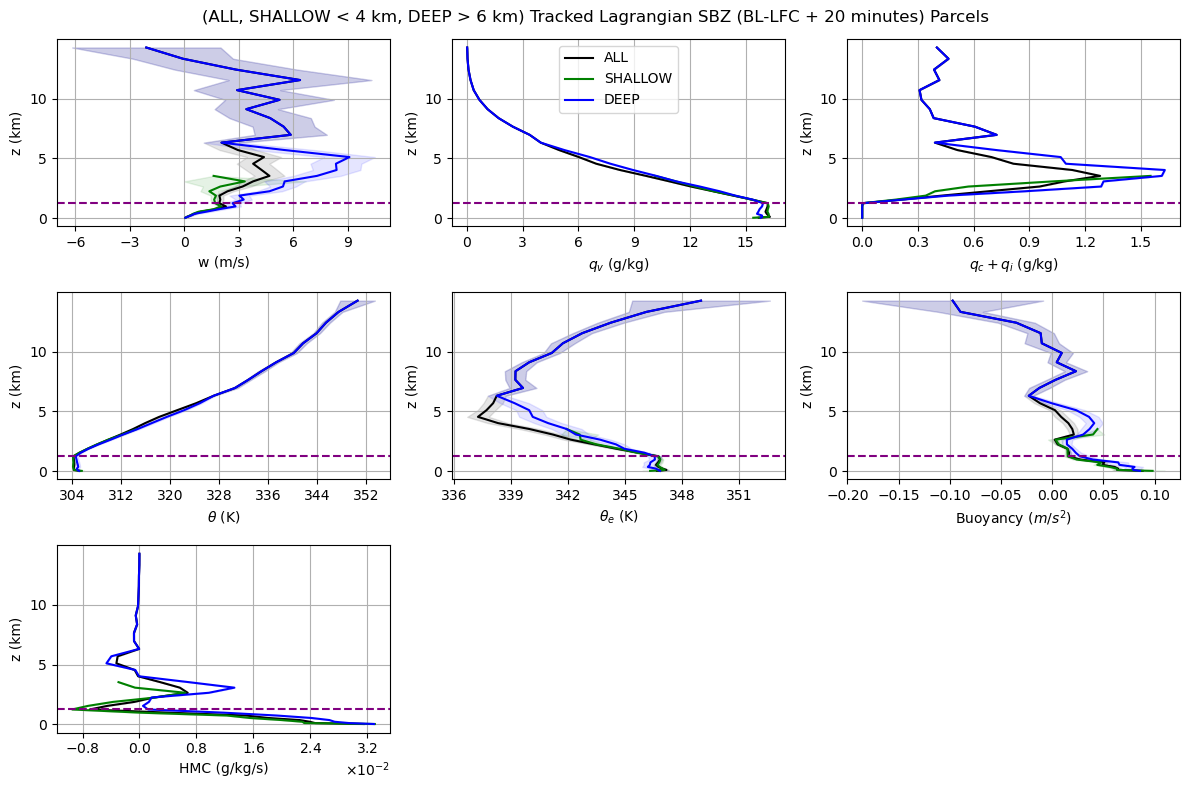

In [64]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_profile_array_w.copy(), SHALLOW_profile_array_w.copy(), DEEP_profile_array_w.copy(), 'w (m/s)'),
    (ALL_profile_array_qv.copy(), SHALLOW_profile_array_qv.copy(), DEEP_profile_array_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_profile_array_qcqi.copy(), SHALLOW_profile_array_qcqi.copy(), DEEP_profile_array_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_profile_array_th.copy(), SHALLOW_profile_array_th.copy(), DEEP_profile_array_th.copy(), r'$\theta$ (K)'),
    (ALL_profile_array_th_e.copy(), SHALLOW_profile_array_th_e.copy(), DEEP_profile_array_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_profile_array_buoyancy.copy(), SHALLOW_profile_array_buoyancy.copy(), DEEP_profile_array_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_profile_array_HMC.copy(), SHALLOW_profile_array_HMC.copy(), DEEP_profile_array_HMC.copy(), 'HMC (g/kg/s)'),
]

############################################################
SE_profiles = [
    (ALL_SE_w.copy(), SHALLOW_SE_w.copy(), DEEP_SE_w.copy(), None),  # Add None for xlabel placeholder
    (ALL_SE_qv.copy(), SHALLOW_SE_qv.copy(), DEEP_SE_qv.copy(), None),
    (ALL_SE_qcqi.copy(), SHALLOW_SE_qcqi.copy(), DEEP_SE_qcqi.copy(), None),
    (ALL_SE_th.copy(), SHALLOW_SE_th.copy(), DEEP_SE_th.copy(), None),
    (ALL_SE_th_e.copy(), SHALLOW_SE_th_e.copy(), DEEP_SE_th_e.copy(), None),
    (ALL_SE_buoyancy.copy(), SHALLOW_SE_buoyancy.copy(), DEEP_SE_buoyancy.copy(), None),
    (ALL_SE_HMC.copy(), SHALLOW_SE_HMC.copy(), DEEP_SE_HMC.copy(), None),
]
############################################################


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

#MATCHING X AXISES WITH NEXT PLOT
#(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
for axis in axs:
    nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
if 'ax8' in globals():
    fix_x_limits([ax1,ax8])
    fix_x_limits([ax2,ax9])
    fix_x_limits([ax3,ax10])
    fix_x_limits([ax4,ax11])
    fix_x_limits([ax5,ax12])
    fix_x_limits([ax6,ax13])
    fix_x_limits([ax7,ax14])
    del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


(-13.378104086968923, 11.317762778504123)
(-0.8038082013217679, 17.110515057952316)
(-0.09328501079277525, 1.9589876078989783)
(301.5398585391725, 382.2584941106467)
(333.8163307200729, 379.89270735599933)
(-0.5484119604181253, 0.18504245047516316)
(-0.01714197438965718, 0.03521309327145474)


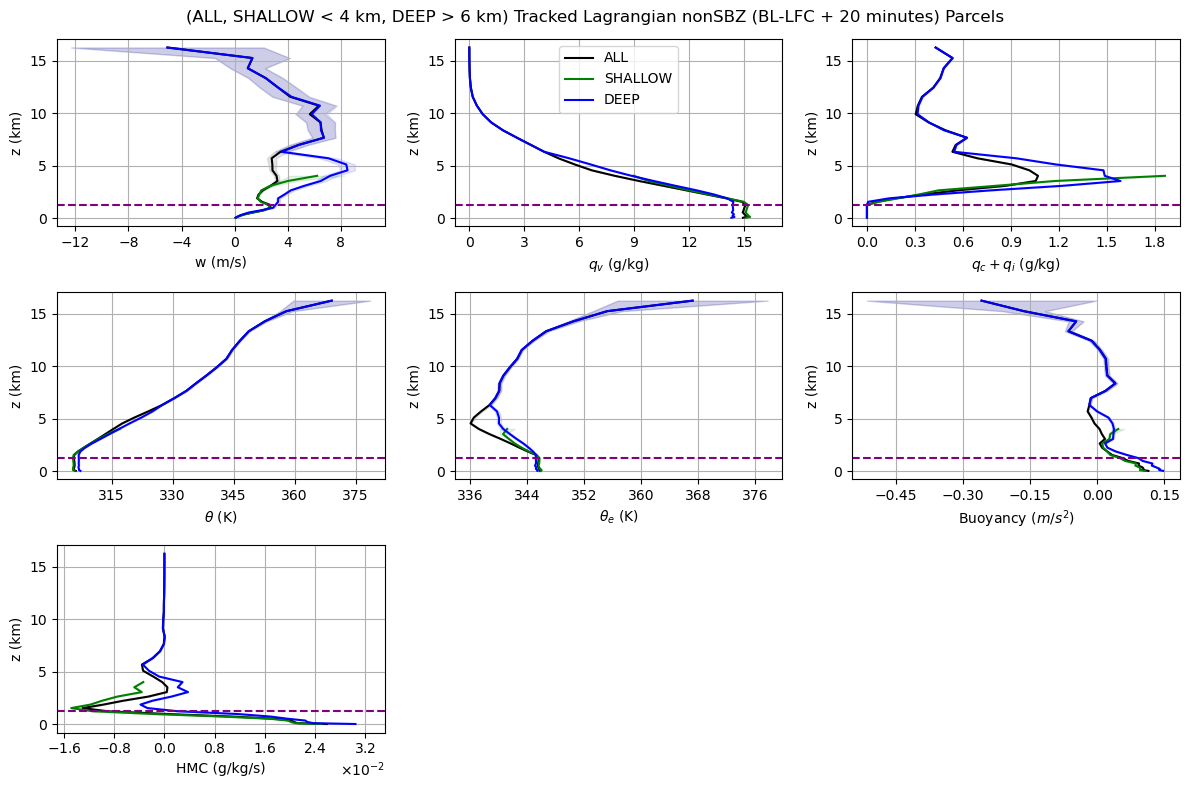

In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (nonSBZ_ALL_profile_array_w.copy(), nonSBZ_SHALLOW_profile_array_w.copy(), nonSBZ_DEEP_profile_array_w.copy(), 'w (m/s)'),
    (nonSBZ_ALL_profile_array_qv.copy(), nonSBZ_SHALLOW_profile_array_qv.copy(), nonSBZ_DEEP_profile_array_qv.copy(), r'$q_v$ (g/kg)'),
    (nonSBZ_ALL_profile_array_qcqi.copy(), nonSBZ_SHALLOW_profile_array_qcqi.copy(), nonSBZ_DEEP_profile_array_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (nonSBZ_ALL_profile_array_th.copy(), nonSBZ_SHALLOW_profile_array_th.copy(), nonSBZ_DEEP_profile_array_th.copy(), r'$\theta$ (K)'),
    (nonSBZ_ALL_profile_array_th_e.copy(), nonSBZ_SHALLOW_profile_array_th_e.copy(), nonSBZ_DEEP_profile_array_th_e.copy(), r'$\theta_e$ (K)'),
    (nonSBZ_ALL_profile_array_buoyancy.copy(), nonSBZ_SHALLOW_profile_array_buoyancy.copy(), nonSBZ_DEEP_profile_array_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (nonSBZ_ALL_profile_array_HMC.copy(), nonSBZ_SHALLOW_profile_array_HMC.copy(), nonSBZ_DEEP_profile_array_HMC.copy(), 'HMC (g/kg/s)'),
]

############################################################
SE_profiles = [
    (nonSBZ_ALL_SE_w.copy(), nonSBZ_SHALLOW_SE_w.copy(), nonSBZ_DEEP_SE_w.copy(), None),  # Add None for xlabel placeholder
    (nonSBZ_ALL_SE_qv.copy(), nonSBZ_SHALLOW_SE_qv.copy(), nonSBZ_DEEP_SE_qv.copy(), None),
    (nonSBZ_ALL_SE_qcqi.copy(), nonSBZ_SHALLOW_SE_qcqi.copy(), nonSBZ_DEEP_SE_qcqi.copy(), None),
    (nonSBZ_ALL_SE_th.copy(), nonSBZ_SHALLOW_SE_th.copy(), nonSBZ_DEEP_SE_th.copy(), None),
    (nonSBZ_ALL_SE_th_e.copy(), nonSBZ_SHALLOW_SE_th_e.copy(), nonSBZ_DEEP_SE_th_e.copy(), None),
    (nonSBZ_ALL_SE_buoyancy.copy(), nonSBZ_SHALLOW_SE_buoyancy.copy(), nonSBZ_DEEP_SE_buoyancy.copy(), None),
    (nonSBZ_ALL_SE_HMC.copy(), nonSBZ_SHALLOW_SE_HMC.copy(), nonSBZ_DEEP_SE_HMC.copy(), None),
]
############################################################

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax8, ax9, ax10, ax11, ax12, ax13, ax14 = axs
for axis in [ax8, ax9, ax10, ax11, ax12, ax13, ax14]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# #FIXING X AXISES TO MATCH PREVIOUS PLOTS
for axis in axs:
    nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
fix_x_limits([ax1,ax8])
fix_x_limits([ax2,ax9])
fix_x_limits([ax3,ax10])
fix_x_limits([ax4,ax11])
fix_x_limits([ax5,ax12])
fix_x_limits([ax6,ax13])
fix_x_limits([ax7,ax14])

In [70]:
#SBZ vs nonSBZ
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
    
# Calculate average differences for each variable (w, qv, qc, th, buoyancy) for SBZ
print('W')
ALL_diff_w = average_difference(ALL_profile_array_w, nonSBZ_ALL_profile_array_w)
SHALLOW_diff_w = average_difference(SHALLOW_profile_array_w, nonSBZ_SHALLOW_profile_array_w)
DEEP_diff_w = average_difference(DEEP_profile_array_w, nonSBZ_DEEP_profile_array_w)

print('QV')
ALL_diff_qv = average_difference(ALL_profile_array_qv, nonSBZ_ALL_profile_array_qv)
SHALLOW_diff_qv = average_difference(SHALLOW_profile_array_qv, nonSBZ_SHALLOW_profile_array_qv)
DEEP_diff_qv = average_difference(DEEP_profile_array_qv, nonSBZ_DEEP_profile_array_qv)

print('QC+QI')
ALL_diff_qcqi = average_difference(ALL_profile_array_qcqi, nonSBZ_ALL_profile_array_qcqi)
SHALLOW_diff_qcqi = average_difference(SHALLOW_profile_array_qcqi, nonSBZ_SHALLOW_profile_array_qcqi)
DEEP_diff_qcqi = average_difference(DEEP_profile_array_qcqi, nonSBZ_DEEP_profile_array_qcqi)

print('TH')
ALL_diff_th = average_difference(ALL_profile_array_th, nonSBZ_ALL_profile_array_th)
SHALLOW_diff_th = average_difference(SHALLOW_profile_array_th, nonSBZ_SHALLOW_profile_array_th)
DEEP_diff_th = average_difference(DEEP_profile_array_th, nonSBZ_DEEP_profile_array_th)

print('TH_E')
ALL_diff_th_e = average_difference(ALL_profile_array_th_e, nonSBZ_ALL_profile_array_th_e)
SHALLOW_diff_th_e = average_difference(SHALLOW_profile_array_th_e, nonSBZ_SHALLOW_profile_array_th_e)
DEEP_diff_th_e = average_difference(DEEP_profile_array_th_e, nonSBZ_DEEP_profile_array_th_e)

print('B')
ALL_diff_buoyancy = average_difference(ALL_profile_array_buoyancy, nonSBZ_ALL_profile_array_buoyancy)
SHALLOW_diff_buoyancy = average_difference(SHALLOW_profile_array_buoyancy, nonSBZ_SHALLOW_profile_array_buoyancy)
DEEP_diff_buoyancy = average_difference(DEEP_profile_array_buoyancy, nonSBZ_DEEP_profile_array_buoyancy)

print('HMC')
ALL_diff_HMC = average_difference(ALL_profile_array_HMC, nonSBZ_ALL_profile_array_HMC)
SHALLOW_diff_HMC = average_difference(SHALLOW_profile_array_HMC, nonSBZ_SHALLOW_profile_array_HMC)
DEEP_diff_HMC = average_difference(DEEP_profile_array_HMC, nonSBZ_DEEP_profile_array_HMC)


W
QV
QC+QI
TH
TH_E
B
HMC


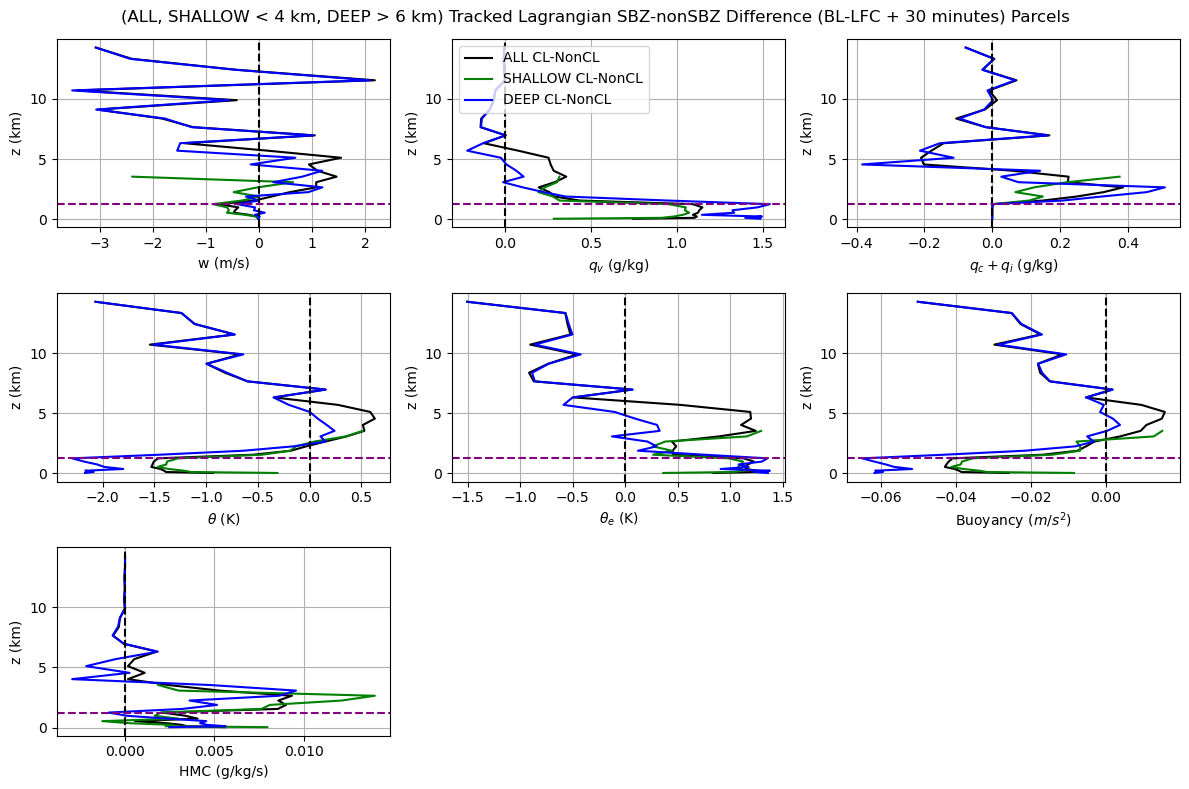

In [71]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_diff_w.copy(), SHALLOW_diff_w.copy(), DEEP_diff_w.copy(), 'w (m/s)'),
    (ALL_diff_qv.copy(), SHALLOW_diff_qv.copy(), DEEP_diff_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_diff_qcqi.copy(), SHALLOW_diff_qcqi.copy(), DEEP_diff_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_diff_th.copy(), SHALLOW_diff_th.copy(), DEEP_diff_th.copy(), r'$\theta$ (K)'),
    (ALL_diff_th_e.copy(), SHALLOW_diff_th_e.copy(), DEEP_diff_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_diff_buoyancy.copy(), SHALLOW_diff_buoyancy.copy(), DEEP_diff_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_diff_HMC.copy(), SHALLOW_diff_HMC.copy(), DEEP_diff_HMC.copy(), 'HMC (g/kg/s)'),
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ-nonSBZ Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [ ]:
#ColdPool
################################################################

In [73]:
#PLOTTING SBZ vs non-SBZ Vertical Profiles
##########################################

#SBZ
def ColdPool_tracked_profile(var_data,type):

    if type=='all':
        out_arr=ALL_ColdPool_out_arr.copy()
        after_array=ALL_ColdPool_after_array
    elif type=='shallow':
        out_arr=SHALLOW_ColdPool_out_arr
        after_array=SHALLOW_ColdPool_after_array
    elif type=='deep':
        out_arr=DEEP_ColdPool_out_arr
        after_array=DEEP_ColdPool_after_array
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        vars=var_data[ts,p]
        np.add.at(profile_array[:, 0], zs, vars)
        np.add.at(profile_array[:, 1], zs, 1)
    return profile_array

print('ALL')
ALL_ColdPool_profile_array_w = ColdPool_tracked_profile(W, type='all')
ALL_ColdPool_profile_array_qv = ColdPool_tracked_profile(QV, type='all')
ALL_ColdPool_profile_array_qcqi = ColdPool_tracked_profile(QCQI, type='all')
ALL_ColdPool_profile_array_th = ColdPool_tracked_profile(TH, type='all')
ALL_ColdPool_profile_array_th_e = ColdPool_tracked_profile(TH_E, type='all')
ALL_ColdPool_profile_array_buoyancy = ColdPool_tracked_profile(BUOYANCY, type='all')
ALL_ColdPool_profile_array_HMC = ColdPool_tracked_profile(HMC, type='all')

print('DEEP')
DEEP_ColdPool_profile_array_w = ColdPool_tracked_profile(W, type='deep')
DEEP_ColdPool_profile_array_qv = ColdPool_tracked_profile(QV, type='deep')
DEEP_ColdPool_profile_array_qcqi = ColdPool_tracked_profile(QCQI, type='deep')
DEEP_ColdPool_profile_array_th = ColdPool_tracked_profile(TH, type='deep')
DEEP_ColdPool_profile_array_th_e = ColdPool_tracked_profile(TH_E, type='deep')
DEEP_ColdPool_profile_array_buoyancy = ColdPool_tracked_profile(BUOYANCY, type='deep')
DEEP_ColdPool_profile_array_HMC = ColdPool_tracked_profile(HMC, type='deep')

print('SHALLOW')
SHALLOW_ColdPool_profile_array_w = ColdPool_tracked_profile(W, type='shallow')
SHALLOW_ColdPool_profile_array_qv = ColdPool_tracked_profile(QV, type='shallow')
SHALLOW_ColdPool_profile_array_qcqi = ColdPool_tracked_profile(QCQI, type='shallow')
SHALLOW_ColdPool_profile_array_th = ColdPool_tracked_profile(TH, type='shallow')
SHALLOW_ColdPool_profile_array_th_e = ColdPool_tracked_profile(TH_E, type='shallow')
SHALLOW_ColdPool_profile_array_buoyancy = ColdPool_tracked_profile(BUOYANCY, type='shallow')
SHALLOW_ColdPool_profile_array_HMC = ColdPool_tracked_profile(HMC, type='shallow')

ALL
DEEP
SHALLOW


In [75]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels
    
def ColdPool_tracked_profile_SE(profile_data,var_data,type):    

    if type=='all':
        out_arr=ALL_ColdPool_out_arr.copy()
        after_array=ALL_ColdPool_after_array
    elif type=='shallow':
        out_arr=SHALLOW_ColdPool_out_arr
        after_array=SHALLOW_ColdPool_after_array
    elif type=='deep':
        out_arr=DEEP_ColdPool_out_arr
        after_array=DEEP_ColdPool_after_array
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;

    for row in range(out_arr.shape[0]):
        after=out_arr[row,3]
        # if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
        p=out_arr[row,0]
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        
        vars=var_data[ts,p]
        mean_mu=profile_data[zs,0]/profile_data[zs,1]
        np.add.at(profile_array[:, 0], zs,  (vars-mean_mu)**2) #SUMMING UP THE SQUARES
        np.add.at(profile_array[:, 1], zs,  1) #SUMMING UP THE SQUARES
    return profile_array


ALL_ColdPool_SE_w = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_w, W, type='all')
SHALLOW_ColdPool_SE_w = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_w, W, type='shallow')
DEEP_ColdPool_SE_w = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_w, W, type='deep')

ALL_ColdPool_SE_qv = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_qv, QV, type='all')
SHALLOW_ColdPool_SE_qv = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_qv, QV, type='shallow')
DEEP_ColdPool_SE_qv = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_qv, QV, type='deep')

ALL_ColdPool_SE_qcqi = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_qcqi, QCQI, type='all')
SHALLOW_ColdPool_SE_qcqi = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_qcqi, QCQI, type='shallow')
DEEP_ColdPool_SE_qcqi = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_qcqi, QCQI, type='deep')

ALL_ColdPool_SE_th = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_th, TH, type='all')
SHALLOW_ColdPool_SE_th = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_th, TH, type='shallow')
DEEP_ColdPool_SE_th = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_th, TH, type='deep')

ALL_ColdPool_SE_th_e = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_th_e, TH_E, type='all')
SHALLOW_ColdPool_SE_th_e = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_th_e, TH_E, type='shallow')
DEEP_ColdPool_SE_th_e = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_th_e, TH_E, type='deep')

ALL_ColdPool_SE_buoyancy = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_buoyancy, BUOYANCY, type='all')
SHALLOW_ColdPool_SE_buoyancy = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_buoyancy, BUOYANCY, type='shallow')
DEEP_ColdPool_SE_buoyancy = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_buoyancy, BUOYANCY, type='deep')

ALL_ColdPool_SE_HMC = ColdPool_tracked_profile_SE(ALL_ColdPool_profile_array_HMC, HMC, type='all')
SHALLOW_ColdPool_SE_HMC = ColdPool_tracked_profile_SE(SHALLOW_ColdPool_profile_array_HMC, HMC, type='shallow')
DEEP_ColdPool_SE_HMC = ColdPool_tracked_profile_SE(DEEP_ColdPool_profile_array_HMC, HMC, type='deep')


In [77]:
#SAVING

# Define categories and variables
types = ["ALL", "SHALLOW", "DEEP"]
variables = ["w", "qv", "qcqi", "th", "th_e", "buoyancy", "HMC"]

# Dictionary to store all variables
tracked_profiles = {}

# Populate all profiles in one loop
for type in types:
    for var in variables:
        tracked_profiles[f"{type}_ColdPool_profile_array_{var}"] = eval(f"{type}_ColdPool_profile_array_{var}")
        tracked_profiles[f"{type}_ColdPool_SE_{var}"] = eval(f"{type}_ColdPool_SE_{var}")

# Save all variables in an HDF5 file
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
output_file=dir2+f"ColdPool_tracked_profiles_{res}_{Np_str}_5min.h5"
with h5py.File(output_file, "w") as h5f:
    for name, profile_data in tracked_profiles.items():
        h5f.create_dataset(name, data=profile_data)
print('done')


done


In [ ]:
#PLOTTING
############################################################

In [79]:

types = ["ALL", "SHALLOW", "DEEP"]
variables = ["w", "qv", "qcqi", "th", "th_e", "buoyancy", "HMC"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"{t}_profile_array_{var}")
        vars_list.append(f"nonSBZ_{t}_profile_array_{var}")
for t in types:
    for var in variables:
        SE_list.append(f"{t}_SE_{var}")
        SE_list.append(f"nonSBZ_{t}_SE_{var}")

# Define directory and output file path
dir2 = dir + 'Project_Algorithms/Tracked_Profiles/job_out2/'
output_file = dir2 + f"SBZ_nonSBZ_tracked_profiles_{res}_{Np_str}_5min.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list + SE_list:
        globals()[var] = f[f'{var}'][:]


In [80]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    where_undefined=np.where(profile[:,1]==1)
    mask=np.where(profile[:,1]!=0)
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 
    profile[where_undefined,0]=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels

In [81]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

(-13.378104086968923, 11.317762778504123)
(-0.8038082013217679, 17.110515057952316)
(-0.09328501079277525, 1.9589876078989783)
(301.5398585391725, 382.2584941106467)
(333.8163307200729, 379.89270735599933)
(-0.5484119604181253, 0.18504245047516316)
(-0.01714197438965718, 0.03521309327145474)


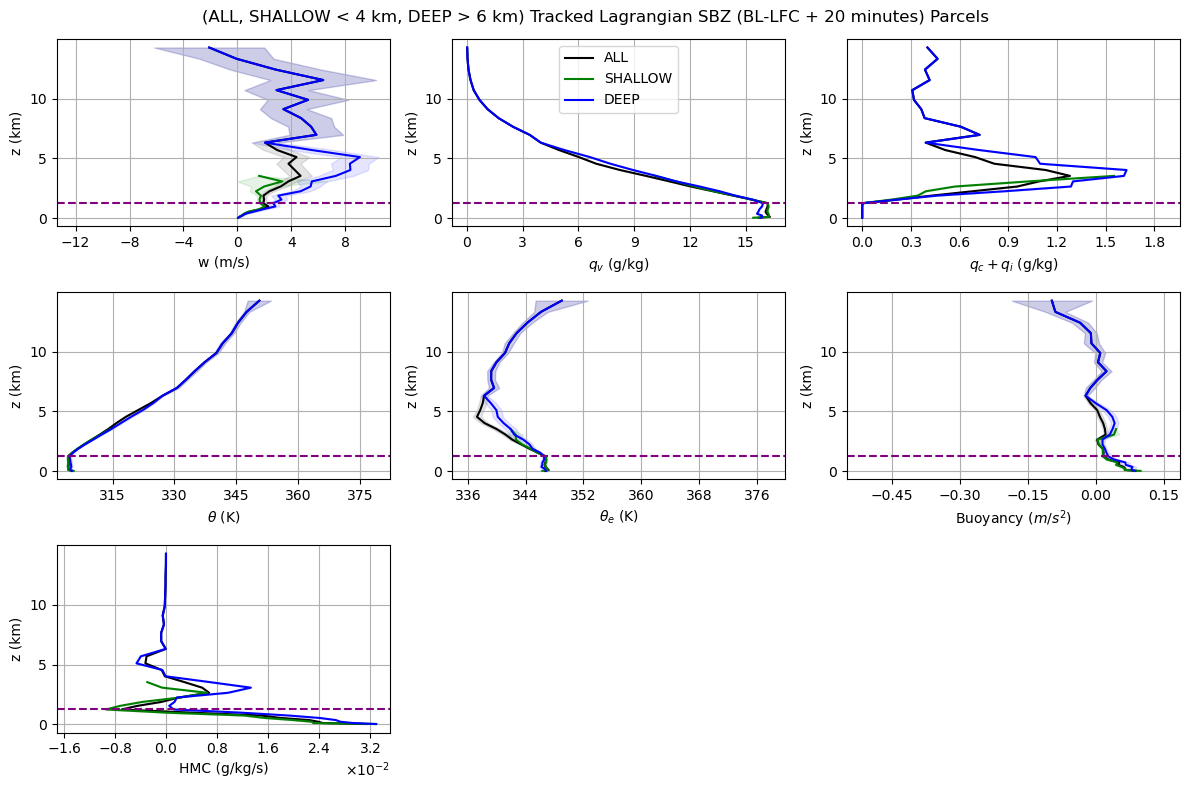

In [82]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_profile_array_w.copy(), SHALLOW_profile_array_w.copy(), DEEP_profile_array_w.copy(), 'w (m/s)'),
    (ALL_profile_array_qv.copy(), SHALLOW_profile_array_qv.copy(), DEEP_profile_array_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_profile_array_qcqi.copy(), SHALLOW_profile_array_qcqi.copy(), DEEP_profile_array_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_profile_array_th.copy(), SHALLOW_profile_array_th.copy(), DEEP_profile_array_th.copy(), r'$\theta$ (K)'),
    (ALL_profile_array_th_e.copy(), SHALLOW_profile_array_th_e.copy(), DEEP_profile_array_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_profile_array_buoyancy.copy(), SHALLOW_profile_array_buoyancy.copy(), DEEP_profile_array_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_profile_array_HMC.copy(), SHALLOW_profile_array_HMC.copy(), DEEP_profile_array_HMC.copy(), 'HMC (g/kg/s)'),
]

############################################################
SE_profiles = [
    (ALL_SE_w.copy(), SHALLOW_SE_w.copy(), DEEP_SE_w.copy(), None),  # Add None for xlabel placeholder
    (ALL_SE_qv.copy(), SHALLOW_SE_qv.copy(), DEEP_SE_qv.copy(), None),
    (ALL_SE_qcqi.copy(), SHALLOW_SE_qcqi.copy(), DEEP_SE_qcqi.copy(), None),
    (ALL_SE_th.copy(), SHALLOW_SE_th.copy(), DEEP_SE_th.copy(), None),
    (ALL_SE_th_e.copy(), SHALLOW_SE_th_e.copy(), DEEP_SE_th_e.copy(), None),
    (ALL_SE_buoyancy.copy(), SHALLOW_SE_buoyancy.copy(), DEEP_SE_buoyancy.copy(), None),
    (ALL_SE_HMC.copy(), SHALLOW_SE_HMC.copy(), DEEP_SE_HMC.copy(), None),
]
############################################################


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

#MATCHING X AXISES WITH NEXT PLOT
#(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
for axis in axs:
    nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
if 'ax8' in globals():
    fix_x_limits([ax1,ax8])
    fix_x_limits([ax2,ax9])
    fix_x_limits([ax3,ax10])
    fix_x_limits([ax4,ax11])
    fix_x_limits([ax5,ax12])
    fix_x_limits([ax6,ax13])
    fix_x_limits([ax7,ax14])
    del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


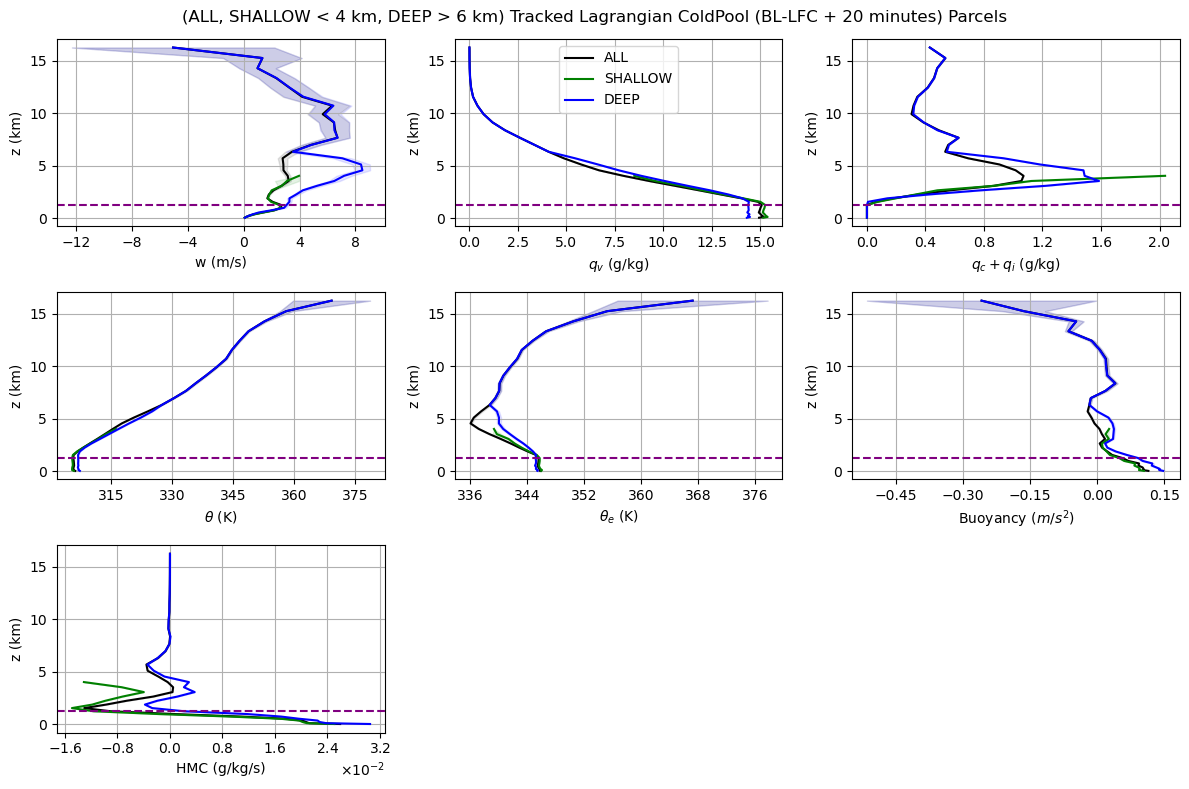

In [83]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_ColdPool_profile_array_w.copy(), SHALLOW_ColdPool_profile_array_w.copy(), DEEP_ColdPool_profile_array_w.copy(), 'w (m/s)'),
    (ALL_ColdPool_profile_array_qv.copy(), SHALLOW_ColdPool_profile_array_qv.copy(), DEEP_ColdPool_profile_array_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_ColdPool_profile_array_qcqi.copy(), SHALLOW_ColdPool_profile_array_qcqi.copy(), DEEP_ColdPool_profile_array_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_ColdPool_profile_array_th.copy(), SHALLOW_ColdPool_profile_array_th.copy(), DEEP_ColdPool_profile_array_th.copy(), r'$\theta$ (K)'),
    (ALL_ColdPool_profile_array_th_e.copy(), SHALLOW_ColdPool_profile_array_th_e.copy(), DEEP_ColdPool_profile_array_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_ColdPool_profile_array_buoyancy.copy(), SHALLOW_ColdPool_profile_array_buoyancy.copy(), DEEP_ColdPool_profile_array_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_ColdPool_profile_array_HMC.copy(), SHALLOW_ColdPool_profile_array_HMC.copy(), DEEP_ColdPool_profile_array_HMC.copy(), 'HMC (g/kg/s)'),
]

############################################################
SE_profiles = [
    (ALL_ColdPool_SE_w.copy(), SHALLOW_ColdPool_SE_w.copy(), DEEP_ColdPool_SE_w.copy(), None),  # Add None for xlabel placeholder
    (ALL_ColdPool_SE_qv.copy(), SHALLOW_ColdPool_SE_qv.copy(), DEEP_ColdPool_SE_qv.copy(), None),
    (ALL_ColdPool_SE_qcqi.copy(), SHALLOW_ColdPool_SE_qcqi.copy(), DEEP_ColdPool_SE_qcqi.copy(), None),
    (ALL_ColdPool_SE_th.copy(), SHALLOW_ColdPool_SE_th.copy(), DEEP_ColdPool_SE_th.copy(), None),
    (ALL_ColdPool_SE_th_e.copy(), SHALLOW_ColdPool_SE_th_e.copy(), DEEP_ColdPool_SE_th_e.copy(), None),
    (ALL_ColdPool_SE_buoyancy.copy(), SHALLOW_ColdPool_SE_buoyancy.copy(), DEEP_ColdPool_SE_buoyancy.copy(), None),
    (ALL_ColdPool_SE_HMC.copy(), SHALLOW_ColdPool_SE_HMC.copy(), DEEP_ColdPool_SE_HMC.copy(), None),
]
############################################################



# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian ColdPool (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

#MATCHING X AXISES WITH NEXT PLOT
#(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
for axis in axs:
    nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
if 'ax8' in globals():
    fix_x_limits([ax1,ax8])
    fix_x_limits([ax2,ax9])
    fix_x_limits([ax3,ax10])
    fix_x_limits([ax4,ax11])
    fix_x_limits([ax5,ax12])
    fix_x_limits([ax6,ax13])
    fix_x_limits([ax7,ax14])
    del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [84]:
#SBZ vs ColdPool
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
    
# Calculate average differences for each variable (w, qv, qc, th, buoyancy) for ColdPool

print('W')
ALL_diff_w = average_difference(ALL_profile_array_w, ALL_ColdPool_profile_array_w)
SHALLOW_diff_w = average_difference(SHALLOW_profile_array_w, SHALLOW_ColdPool_profile_array_w)
DEEP_diff_w = average_difference(DEEP_profile_array_w, DEEP_ColdPool_profile_array_w)

print('QV')
ALL_diff_qv = average_difference(ALL_profile_array_qv, ALL_ColdPool_profile_array_qv)
SHALLOW_diff_qv = average_difference(SHALLOW_profile_array_qv, SHALLOW_ColdPool_profile_array_qv)
DEEP_diff_qv = average_difference(DEEP_profile_array_qv, DEEP_ColdPool_profile_array_qv)

print('QC+QI')
ALL_diff_qcqi = average_difference(ALL_profile_array_qcqi, ALL_ColdPool_profile_array_qcqi)
SHALLOW_diff_qcqi = average_difference(SHALLOW_profile_array_qcqi, SHALLOW_ColdPool_profile_array_qcqi)
DEEP_diff_qcqi = average_difference(DEEP_profile_array_qcqi, DEEP_ColdPool_profile_array_qcqi)

print('TH')
ALL_diff_th = average_difference(ALL_profile_array_th, ALL_ColdPool_profile_array_th)
SHALLOW_diff_th = average_difference(SHALLOW_profile_array_th, SHALLOW_ColdPool_profile_array_th)
DEEP_diff_th = average_difference(DEEP_profile_array_th, DEEP_ColdPool_profile_array_th)

print('TH_E')
ALL_diff_th_e = average_difference(ALL_profile_array_th_e, ALL_ColdPool_profile_array_th_e)
SHALLOW_diff_th_e = average_difference(SHALLOW_profile_array_th_e, SHALLOW_ColdPool_profile_array_th_e)
DEEP_diff_th_e = average_difference(DEEP_profile_array_th_e, DEEP_ColdPool_profile_array_th_e)

print('B')
ALL_diff_buoyancy = average_difference(ALL_profile_array_buoyancy, ALL_ColdPool_profile_array_buoyancy)
SHALLOW_diff_buoyancy = average_difference(SHALLOW_profile_array_buoyancy, SHALLOW_ColdPool_profile_array_buoyancy)
DEEP_diff_buoyancy = average_difference(DEEP_profile_array_buoyancy, DEEP_ColdPool_profile_array_buoyancy)

print('HMC')
ALL_diff_HMC = average_difference(ALL_profile_array_HMC, ALL_ColdPool_profile_array_HMC)
SHALLOW_diff_HMC = average_difference(SHALLOW_profile_array_HMC, SHALLOW_ColdPool_profile_array_HMC)
DEEP_diff_HMC = average_difference(DEEP_profile_array_HMC, DEEP_ColdPool_profile_array_HMC)


W
QV
QC+QI
TH
TH_E
B
HMC


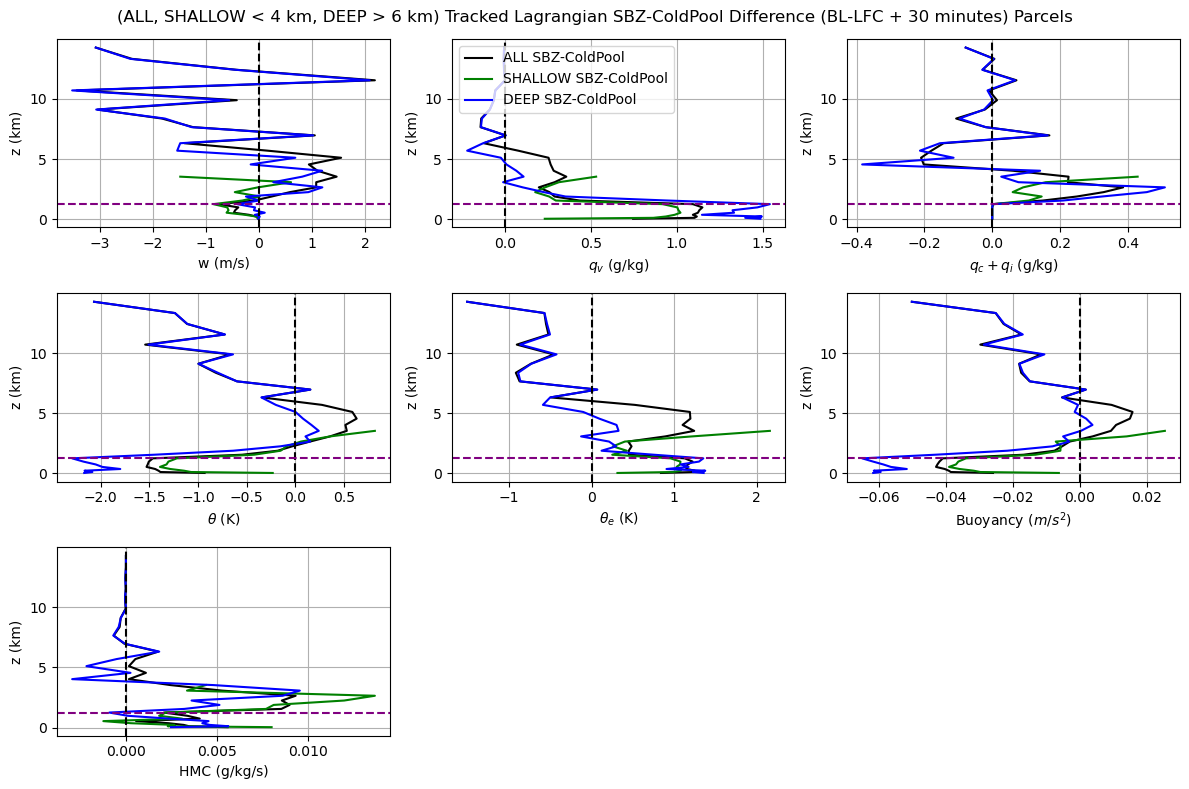

In [85]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (ALL_diff_w.copy(), SHALLOW_diff_w.copy(), DEEP_diff_w.copy(), 'w (m/s)'),
    (ALL_diff_qv.copy(), SHALLOW_diff_qv.copy(), DEEP_diff_qv.copy(), r'$q_v$ (g/kg)'),
    (ALL_diff_qcqi.copy(), SHALLOW_diff_qcqi.copy(), DEEP_diff_qcqi.copy(), r'$q_c+q_i$ (g/kg)'),
    (ALL_diff_th.copy(), SHALLOW_diff_th.copy(), DEEP_diff_th.copy(), r'$\theta$ (K)'),
    (ALL_diff_th_e.copy(), SHALLOW_diff_th_e.copy(), DEEP_diff_th_e.copy(), r'$\theta_e$ (K)'),
    (ALL_diff_buoyancy.copy(), SHALLOW_diff_buoyancy.copy(), DEEP_diff_buoyancy.copy(), 'Buoyancy '+r'$(m/s^2)$'),
    (ALL_diff_HMC.copy(), SHALLOW_diff_HMC.copy(), DEEP_diff_HMC.copy(), 'HMC (g/kg/s)'),
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-ColdPool')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-ColdPool')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-ColdPool')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ-ColdPool Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()

